
### Imports and global setup

This notebook constructs a synthetic local galaxy catalog for use in downstream transient simulations.
Standard scientific Python libraries are imported, and a fixed random seed is set to ensure reproducibility.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


### Global parameters

We define the size of the local Universe and the total number of galaxies in the synthetic catalog.
The Universe is assumed to be local, Euclidean, and non-evolving.


In [2]:
# Universe parameters
R_MAX = 300.0          # Mpc
N_GALAXIES = 50_000    # size of galaxy catalog


### Galaxy positions

Galaxy positions are drawn uniformly in three-dimensional volume within a spherical region of radius 300 Mpc.
The radial distribution scales as r ∝ u^{1/3} to ensure constant number density.


In [3]:
u = np.random.uniform(0, 1, N_GALAXIES)
r = R_MAX * u**(1/3)

theta = np.arccos(1 - 2 * np.random.uniform(0, 1, N_GALAXIES))
phi = 2 * np.pi * np.random.uniform(0, 1, N_GALAXIES)

x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)


### Galaxy distances

The distance to each galaxy is computed from its three-dimensional Cartesian coordinates.
This distance is used later when applying observational selection effects.


In [4]:
distance = np.sqrt(x**2 + y**2 + z**2)


### Stellar mass distribution

Galaxy stellar masses are drawn from a Schechter-like mass function.
This provides a realistic mass distribution while remaining a simple toy model.


In [5]:
alpha_m = -1.3
M_star_char = 1e10      # solar masses
M_min = 1e8
M_max = 1e12

def sample_schechter_mass(N, alpha, M_star, M_min, M_max):
    M = []
    while len(M) < N:
        M_trial = 10**np.random.uniform(np.log10(M_min), np.log10(M_max))
        y = np.random.uniform(0, 1)
        phi = (M_trial / M_star)**alpha * np.exp(-M_trial / M_star)
        phi_max = (M_min / M_star)**alpha
        if y < phi / phi_max:
            M.append(M_trial)
    return np.array(M)

M_star = sample_schechter_mass(
    N_GALAXIES, alpha_m, M_star_char, M_min, M_max
)


### Quiescent galaxy assignment

Each galaxy is assigned a probability of being quiescent that depends on stellar mass.
This reproduces the observed increase in quiescent fraction with mass in a simplified form.


In [6]:
def quiescent_fraction(logM):
    return np.clip(0.2 + 0.15 * (logM - 9.5), 0.0, 0.9)

logM = np.log10(M_star)
fq = quiescent_fraction(logM)
is_quiescent = np.random.uniform(0, 1, N_GALAXIES) < fq


### Star-formation rates

Star-forming galaxies are assigned star-formation rates following a mass-dependent main sequence with scatter.
Quiescent galaxies have their star-formation rates suppressed relative to the main sequence.


In [7]:
# Star-forming main sequence
logSFR_MS = 0.8 * (logM - 10) - 0.3
scatter = np.random.normal(0, 0.3, N_GALAXIES)

logSFR = logSFR_MS + scatter

# Suppress quiescent galaxies
logSFR[is_quiescent] = logSFR[is_quiescent] - 2.0

SFR = 10**logSFR
SFR[SFR < 0] = 0.0


### Galaxy luminosities

Galaxy luminosities are drawn independently from a Schechter luminosity function.
A single-band luminosity is assumed, with no dust, K-corrections, or redshift evolution.


In [8]:
alpha_L = -1.1
L_star = 1.0
L_min = 1e-3
L_max = 50.0

def sample_schechter_L(N, alpha, L_star, L_min, L_max):
    L = []
    while len(L) < N:
        L_trial = 10**np.random.uniform(np.log10(L_min), np.log10(L_max))
        y = np.random.uniform(0, 1)
        phi = (L_trial / L_star)**alpha * np.exp(-L_trial / L_star)
        phi_max = (L_min / L_star)**alpha
        if y < phi / phi_max:
            L.append(L_trial)
    return np.array(L)

L = sample_schechter_L(
    N_GALAXIES, alpha_L, L_star, L_min, L_max
)


### Galaxy catalog assembly

All galaxy properties are combined into a single table.
This catalog is reused in subsequent notebooks for event injection and detection studies.


In [18]:
galaxies = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "distance": distance,
    "M_star": M_star,
    "SFR": SFR,
    "is_quiescent": is_quiescent,
    "L": L
})


### Validation: mass–SFR relation

The mass–star-formation-rate plane is plotted to verify the presence of a star-forming main sequence and a quiescent population.
This plot is used as a sanity check only.


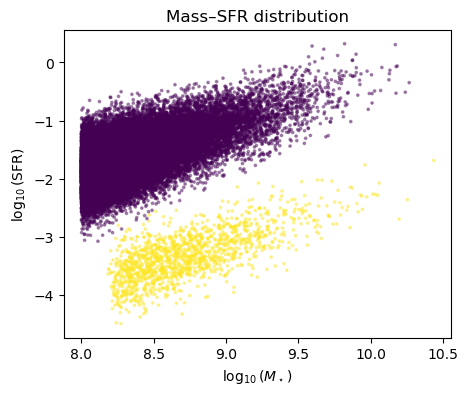

In [10]:
plt.figure(figsize=(5, 4))
plt.scatter(np.log10(galaxies["M_star"]),
            np.log10(galaxies["SFR"] + 1e-6),
            c=galaxies["is_quiescent"],
            s=3,
            alpha=0.4)
plt.xlabel(r"$\log_{10}(M_\star)$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR})$")
plt.title("Mass–SFR distribution")
plt.show()


### Validation: spatial and luminosity distribution

Purple points indicate star-forming galaxies following a mass-dependent star-formation main sequence.
Yellow points indicate quiescent galaxies with suppressed star-formation rates.


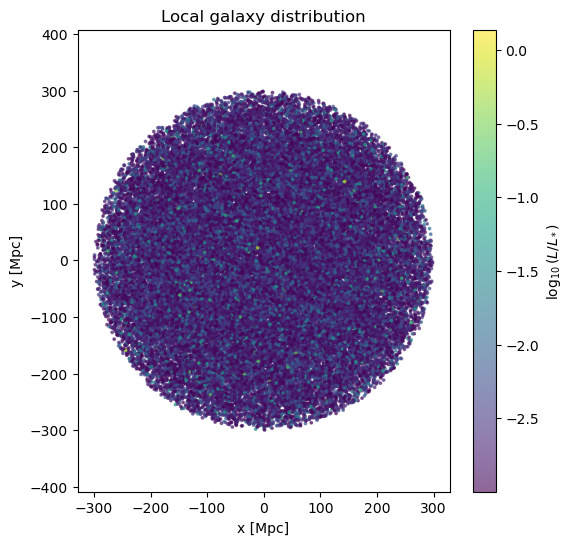

In [11]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(galaxies["x"], galaxies["y"],
                 c=np.log10(galaxies["L"]),
                 s=3,
                 cmap="viridis",
                 alpha=0.6)
plt.xlabel("x [Mpc]")
plt.ylabel("y [Mpc]")
plt.colorbar(sc, label=r"$\log_{10}(L/L_*)$")
plt.title("Local galaxy distribution")
plt.axis("equal")
plt.show()


### Interpretation of the local galaxy distribution

Each point represents a galaxy projected onto the x–y plane and coloured by luminosity.
Most galaxies appear faint because the Schechter luminosity function is steep at low luminosities, meaning low-luminosity galaxies are far more numerous than bright ones.
Bright galaxies are therefore rare and visually outnumbered, even though they are distributed uniformly across the volume.
No spatial clustering is included by design.


In [12]:
galaxies.to_csv("galaxy_catalog.csv", index=False)
